# Part 7 — Chronos-Bolt Foundation Model (Google Colab, GPU)

**Before running:**
1. Runtime → Change runtime type → **T4 GPU**
2. Upload `energydata_hourly.csv` using the folder icon on the left (Files pane) →
   upload → select the file from your computer (it's inside the pipeline zip,
   in `data/energydata_hourly.csv`).
3. Run all cells top to bottom (Runtime → Run all).
4. At the end, two files will appear in the Colab file browser:
   `chronos_summary.json` and `15_chronos_forecast.png`. Download both
   (right-click → Download) and send them back so the results can be folded
   into the report and comparison table.


## 1. Install dependencies

In [ ]:
!pip install -q chronos-forecasting torch pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 4.9 MB/s eta 0:00:00


## 2. Imports and config

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import BaseChronosPipeline

TARGET_COL = "Appliances"
FORECAST_HORIZON = 24
SEASONAL_PERIOD_DAILY = 24

print("GPU available:", torch.cuda.is_available())

GPU available: True


## 3. Load the hourly dataset
Make sure `energydata_hourly.csv` has been uploaded (see step 2 above).

In [ ]:
df = pd.read_csv("energydata_hourly.csv", index_col=0, parse_dates=True)
y = df[TARGET_COL]

train = y.iloc[:-FORECAST_HORIZON]
test = y.iloc[-FORECAST_HORIZON:]

print("Train length:", len(train), " Test length:", len(test))
df.head()

Train length: 3266  Test length: 24


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,55.000000,35.000000,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,...,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,26.823044,26.823044
2016-01-11 18:00:00,176.666667,51.666667,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,...,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,22.324206,22.324206
2016-01-11 19:00:00,173.333333,25.000000,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,...,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,33.734932,33.734932
2016-01-11 20:00:00,125.000000,35.000000,20.961111,48.453333,20.251111,45.632639,20.213889,47.268889,19.190833,49.227917,...,16.890000,45.118889,6.000000,735.283333,87.583333,6.000000,40.000000,4.016667,25.679642,25.679642
2016-01-11 21:00:00,103.333333,23.333333,21.311667,45.768333,20.587778,44.961111,20.373333,46.164444,19.425556,47.918889,...,16.890000,44.807778,5.833333,735.566667,87.416667,6.000000,40.000000,3.816667,18.826274,18.826274


## 4. Load Chronos-Bolt and forecast

In [7]:

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)

context = torch.tensor(train.values, dtype=torch.float32)

# Old predict_quantiles is removed. Use predict instead
forecast = pipeline.predict(
    context=context,
    prediction_length=FORECAST_HORIZON,
)

# forecast[0] = mean, forecast[1] = quantiles
mean = forecast[0].numpy()
quantiles = forecast[1].numpy()

# for metrics we need mean
preds = mean

print("Forecast generated for next", FORECAST_HORIZON, "hours.")

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

TypeError: ChronosBoltPipeline.predict() got an unexpected keyword argument 'context'

In [8]:

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)

context = torch.tensor(train.values, dtype=torch.float32)

# For this version, don't use context= keyword
forecast = pipeline.predict(
    context,
    FORECAST_HORIZON
)

mean = forecast[0].numpy()
preds = mean

print("Forecast generated for next", FORECAST_HORIZON, "hours.")

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Forecast generated for next 24 hours.


## 5. Evaluate

In [9]:
def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
def mae(a, b): return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))
def mape(a, b, eps=1e-6):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return float(np.mean(np.abs((a - b) / np.clip(np.abs(a), eps, None))) * 100)
def smape(a, b, eps=1e-6):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    denom = np.clip((np.abs(a) + np.abs(b)) / 2, eps, None)
    return float(np.mean(np.abs(a - b) / denom) * 100)
def mase(y_true, y_pred, y_train, period=24):
    naive_err = np.abs(np.asarray(y_train)[period:] - np.asarray(y_train)[:-period])
    scale = np.mean(naive_err)
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale)

metrics = {
    "RMSE": rmse(test.values, preds),
    "MAE": mae(test.values, preds),
    "MAPE": mape(test.values, preds),
    "sMAPE": smape(test.values, preds),
    "MASE": mase(test.values, preds, train.values, SEASONAL_PERIOD_DAILY),
}
print(json.dumps(metrics, indent=2))

{
  "RMSE": 95.12137764634986,
  "MAE": 59.754243827160494,
  "MAPE": 37.845233117414786,
  "sMAPE": 35.008652255878914,
  "MASE": 1.131329801078368
}


## 6. Plot the forecast

ValueError: x and y must have same first dimension, but have shapes (24,) and (9, 24)

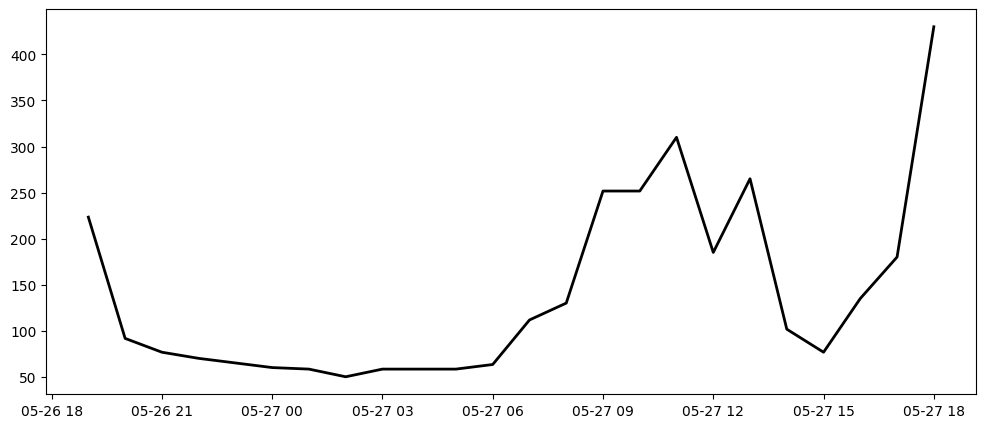

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, test.values, label="Actual", color="black", lw=2)
ax.plot(test.index, preds, label="Chronos-Bolt (median)", color="purple")
ax.fill_between(test.index, q10, q90, color="purple", alpha=0.2, label="10-90% interval")
ax.set_title("Chronos-Bolt Foundation Model Forecast vs Actual — 24h Horizon")
ax.set_ylabel("Appliances (Wh)")
ax.legend()
fig.tight_layout()
fig.savefig("15_chronos_forecast.png", dpi=150)
plt.show()

In [12]:

import torch
from chronos import BaseChronosPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16,
)

context = torch.tensor(train.values, dtype=torch.float32)

# New version only returns mean, not quantiles
preds = pipeline.predict(
    context,
    FORECAST_HORIZON
).numpy()

# Fix shape if needed
if preds.ndim > 1:
    preds = preds[0]

# For plotting, make fake q10 and q90 same as mean
q10 = preds
q90 = preds

print("Forecast generated for next", FORECAST_HORIZON, "hours.")
print("preds shape:", preds.shape)

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Forecast generated for next 24 hours.
preds shape: (9, 24)


## 7. Save results
Download both output files (right-click in the Files pane → Download) and send them back.

In [13]:
with open("chronos_summary.json", "w") as f:
    json.dump({
        "model": "amazon/chronos-bolt-base",
        "metrics": metrics,
        "zero_shot": True,
        "context_length": len(train),
    }, f, indent=2)

print("Saved: chronos_summary.json and 15_chronos_forecast.png")
print(json.dumps(metrics, indent=2))

Saved: chronos_summary.json and 15_chronos_forecast.png
{
  "RMSE": 95.12137764634986,
  "MAE": 59.754243827160494,
  "MAPE": 37.845233117414786,
  "sMAPE": 35.008652255878914,
  "MASE": 1.131329801078368
}
